In [ ]:
# ============================================================
# CELL 0: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Old folder — read input files from here
DRIVE_PATH_OLD = '/content/drive/MyDrive/Colab Notebooks/'

# New folder — save all output files here
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/SERWI_Results/'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('Drive mounted successfully.')
print()
print(f'Input  folder : {DRIVE_PATH_OLD}')
print(f'Output folder : {DRIVE_PATH}')
print()

# Safety check — old files untouched
print('=== OLD FILES SAFETY CHECK ===')
old_check = [
    'xgb_lstm_y_pred_test.npy',
    'XGB_LSTM_Actual_vs_Predicted.png',
    'XGB_LSTM_Residuals.png',
]
for f in old_check:
    status = '✓ Safe' if os.path.exists(DRIVE_PATH_OLD + f) else '— Not found'
    print(f'  {status}  {f}')

print()

# Check required input files
required_files = [
    'xgb_y_pred_test.npy', 'xgb_y_pred_train.npy',
    'xgb_y_test.npy',      'xgb_y_train.npy',
    'xgb_yr_test.npy',     'xgb_dist_test.npy',
    'xgb_trend_test.npy',  'xgb_trend_train.npy',
    'lstm_y_pred_test.npy','lstm_y_pred_train.npy',
    'lstm_y_test.npy',     'lstm_y_train.npy',
    'lstm_yr_test.npy',    'lstm_dist_test.npy',
    'lstm_trend_test.npy', 'lstm_trend_train.npy',
]

print('=== CHECKING REQUIRED INPUT FILES ===')
missing = []
for f in required_files:
    path = DRIVE_PATH_OLD + f
    if os.path.exists(path):
        print(f'  ✓  {f}')
    else:
        print(f'  ✗  MISSING: {f}')
        missing.append(f)

print()
if missing:
    print(f'WARNING: {len(missing)} file(s) missing.')
else:
    print('All input files found. Ready to proceed.')
    print('New output files will save to SERWI_Results/ folder.')

Mounted at /content/drive
Drive mounted successfully.

Input  folder : /content/drive/MyDrive/Colab Notebooks/
Output folder : /content/drive/MyDrive/Colab Notebooks/SERWI_Results/

=== OLD FILES SAFETY CHECK ===
  ✓ Safe  xgb_lstm_y_pred_test.npy
  ✓ Safe  XGB_LSTM_Actual_vs_Predicted.png
  ✓ Safe  XGB_LSTM_Residuals.png

=== CHECKING REQUIRED INPUT FILES ===
  ✓  xgb_y_pred_test.npy
  ✓  xgb_y_pred_train.npy
  ✓  xgb_y_test.npy
  ✓  xgb_y_train.npy
  ✓  xgb_yr_test.npy
  ✓  xgb_dist_test.npy
  ✓  xgb_trend_test.npy
  ✓  xgb_trend_train.npy
  ✓  lstm_y_pred_test.npy
  ✓  lstm_y_pred_train.npy
  ✓  lstm_y_test.npy
  ✓  lstm_y_train.npy
  ✓  lstm_yr_test.npy
  ✓  lstm_dist_test.npy
  ✓  lstm_trend_test.npy
  ✓  lstm_trend_train.npy

All input files found. Ready to proceed.
New output files will save to SERWI_Results/ folder.


In [ ]:
# ============================================================
# CELL 1: Libraries + Load Predictions
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from scipy.optimize import minimize

SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')
print()

# Load from OLD folder
xgb_y_pred_test  = np.load(DRIVE_PATH_OLD + 'xgb_y_pred_test.npy')
xgb_y_pred_train = np.load(DRIVE_PATH_OLD + 'xgb_y_pred_train.npy')
xgb_y_test       = np.load(DRIVE_PATH_OLD + 'xgb_y_test.npy')
xgb_y_train      = np.load(DRIVE_PATH_OLD + 'xgb_y_train.npy')
xgb_yr_test      = np.load(DRIVE_PATH_OLD + 'xgb_yr_test.npy')
xgb_dist_test    = np.load(DRIVE_PATH_OLD + 'xgb_dist_test.npy',  allow_pickle=True)
xgb_trend_test   = np.load(DRIVE_PATH_OLD + 'xgb_trend_test.npy')
xgb_trend_train  = np.load(DRIVE_PATH_OLD + 'xgb_trend_train.npy')

lstm_y_pred_test  = np.load(DRIVE_PATH_OLD + 'lstm_y_pred_test.npy')
lstm_y_pred_train = np.load(DRIVE_PATH_OLD + 'lstm_y_pred_train.npy')
lstm_y_test       = np.load(DRIVE_PATH_OLD + 'lstm_y_test.npy')
lstm_y_train      = np.load(DRIVE_PATH_OLD + 'lstm_y_train.npy')
lstm_yr_test      = np.load(DRIVE_PATH_OLD + 'lstm_yr_test.npy')
lstm_dist_test    = np.load(DRIVE_PATH_OLD + 'lstm_dist_test.npy', allow_pickle=True)
lstm_trend_test   = np.load(DRIVE_PATH_OLD + 'lstm_trend_test.npy')
lstm_trend_train  = np.load(DRIVE_PATH_OLD + 'lstm_trend_train.npy')

print('=== LOADED ARRAYS ===')
print(f'XGBoost - Train: {xgb_y_pred_train.shape}  Test: {xgb_y_pred_test.shape}')
print(f'LSTM    - Train: {lstm_y_pred_train.shape}  Test: {lstm_y_pred_test.shape}')
print()

# Align
n_train_xgb  = len(xgb_y_pred_train)
n_train_lstm = len(lstm_y_pred_train)
offset = n_train_xgb - n_train_lstm

xgb_y_pred_train_aligned = xgb_y_pred_train[offset:]
xgb_y_train_aligned      = xgb_y_train[offset:]
lstm_y_pred_train_aligned = lstm_y_pred_train
lstm_y_train_aligned      = lstm_y_train

print(f'Aligned train samples : {len(xgb_y_pred_train_aligned)}')
print(f'Test    samples       : {len(xgb_y_pred_test)}')
print()

assert len(xgb_y_pred_train_aligned) == len(lstm_y_pred_train_aligned)
assert len(xgb_y_pred_test) == len(lstm_y_pred_test)
print('✓ Array alignment verified.')
print()

r2_xgb  = r2_score(xgb_y_test,  xgb_y_pred_test)
r2_lstm = r2_score(lstm_y_test, lstm_y_pred_test)

print('=== STANDALONE BASELINES ===')
print(f'  XGBoost R² : {r2_xgb:.4f}')
print(f'  LSTM    R² : {r2_lstm:.4f}')
print(f'  TCN     R² : 0.4849  (reference)')

All libraries loaded successfully.

=== LOADED ARRAYS ===
XGBoost - Train: (76,)  Test: (20,)
LSTM    - Train: (64,)  Test: (20,)

Aligned train samples : 64
Test    samples       : 20

✓ Array alignment verified.

=== STANDALONE BASELINES ===
  XGBoost R² : 0.1698
  LSTM    R² : 0.2945
  TCN     R² : 0.4849  (reference)


In [ ]:
# ============================================================
# CELL 2: XGBoost + LSTM Hybrid
# Error-Decorrelation Blend
# Note: SERWI does not improve XGB+LSTM because XGBoost
# has near-zero train R² — result consistent with literature
# ============================================================
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{name}')
    print(f'  R²   : {r2:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print()
    return r2, rmse, mae

districts   = ['Khanewal', 'Lodhran', 'Multan', 'Vehari']
dist_labels = lstm_dist_test
yr_labels   = lstm_yr_test.astype(int)
y_true      = lstm_y_test.copy()

print('=== BASELINES ===')
r2_xgb,  rmse_xgb,  mae_xgb  = evaluate(y_true, xgb_y_pred_test,  'XGBoost')
r2_lstm, rmse_lstm, mae_lstm  = evaluate(y_true, lstm_y_pred_test, 'LSTM')
print('TCN reference R² = 0.4849')
print()

# Error Decorrelation Blend
err_xgb  = xgb_y_train_aligned  - xgb_y_pred_train_aligned
err_lstm = lstm_y_train_aligned - lstm_y_pred_train_aligned
corr     = np.corrcoef(err_xgb, err_lstm)[0, 1]
print(f'Train error correlation: {corr:.4f}')
print()

w_lstm = np.clip(0.7 + 0.2*(1-corr), 0.6, 0.9)
w_xgb  = 1 - w_lstm

y_pred_hybrid = (
    w_lstm * lstm_y_pred_test +
    w_xgb  * xgb_y_pred_test +
    0.15   * (lstm_y_pred_test - xgb_y_pred_test)
)

r2_hyb, rmse_hyb, mae_hyb = evaluate(y_true, y_pred_hybrid, 'XGB+LSTM Hybrid')

print('=' * 52)
print('   XGBoost + LSTM HYBRID — FINAL RESULT')
print('=' * 52)
print(f'  Strategy   : Error-Decorrelation Blend')
print(f'  XGB weight : {w_xgb:.4f}')
print(f'  LSTM weight: {w_lstm:.4f}')
print()
print(f'  R²   : {r2_hyb:.4f}')
print(f'  RMSE : {rmse_hyb:.4f} maund/acre')
print(f'  MAE  : {mae_hyb:.4f} maund/acre')
print('=' * 52)
print()
print('=== STANDALONE MODEL COMPARISON ===')
print(f'  {"Model":<20} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 46)
print(f'  {"XGBoost":<20} {r2_xgb:>8.4f} {rmse_xgb:>8.4f} {mae_xgb:>8.4f}')
print(f'  {"LSTM":<20} {r2_lstm:>8.4f} {rmse_lstm:>8.4f} {mae_lstm:>8.4f}')
print(f'  {"XGB+LSTM Hybrid":<20} {r2_hyb:>8.4f} {rmse_hyb:>8.4f} {mae_hyb:>8.4f}')
print(f'  {"TCN (reference)":<20} {"0.4849":>8} {"1.5592":>8} {"1.3436":>8}')
print('=' * 52)

=== BASELINES ===
XGBoost
  R²   : 0.1698
  RMSE : 1.9794
  MAE  : 1.5916

LSTM
  R²   : 0.2945
  RMSE : 1.8247
  MAE  : 1.5002

TCN reference R² = 0.4849

Train error correlation: -0.1155

XGB+LSTM Hybrid
  R²   : 0.2950
  RMSE : 1.8241
  MAE  : 1.4963

   XGBoost + LSTM HYBRID — FINAL RESULT
  Strategy   : Error-Decorrelation Blend
  XGB weight : 0.1000
  LSTM weight: 0.9000

  R²   : 0.2950
  RMSE : 1.8241 maund/acre
  MAE  : 1.4963 maund/acre

=== STANDALONE MODEL COMPARISON ===
  Model                      R²     RMSE      MAE
  ----------------------------------------------
  XGBoost                0.1698   1.9794   1.5916
  LSTM                   0.2945   1.8247   1.5002
  XGB+LSTM Hybrid        0.2950   1.8241   1.4963
  TCN (reference)        0.4849   1.5592   1.3436


Actual vs Predicted (Test Set 2021-2025):
 Year District  Actual  Predicted  Error
 2021 Khanewal   33.80      36.38  -2.58
 2022 Khanewal   37.30      37.12   0.18
 2023 Khanewal   37.90      37.43   0.47
 2024 Khanewal   39.60      37.72   1.88
 2025 Khanewal   40.60      38.15   2.45
 2021  Lodhran   34.20      38.37  -4.17
 2022  Lodhran   38.10      39.41  -1.31
 2023  Lodhran   38.70      40.11  -1.41
 2024  Lodhran   40.10      40.57  -0.47
 2025  Lodhran   40.14      41.00  -0.86
 2021   Multan   34.50      35.03  -0.53
 2022   Multan   36.70      35.99   0.71
 2023   Multan   37.50      36.37   1.13
 2024   Multan   39.90      36.84   3.06
 2025   Multan   38.93      37.03   1.90
 2021   Vehari   35.30      36.44  -1.14
 2022   Vehari   35.30      37.17  -1.87
 2023   Vehari   37.60      37.66  -0.06
 2024   Vehari   40.70      38.06   2.64
 2025   Vehari   39.70      38.60   1.10



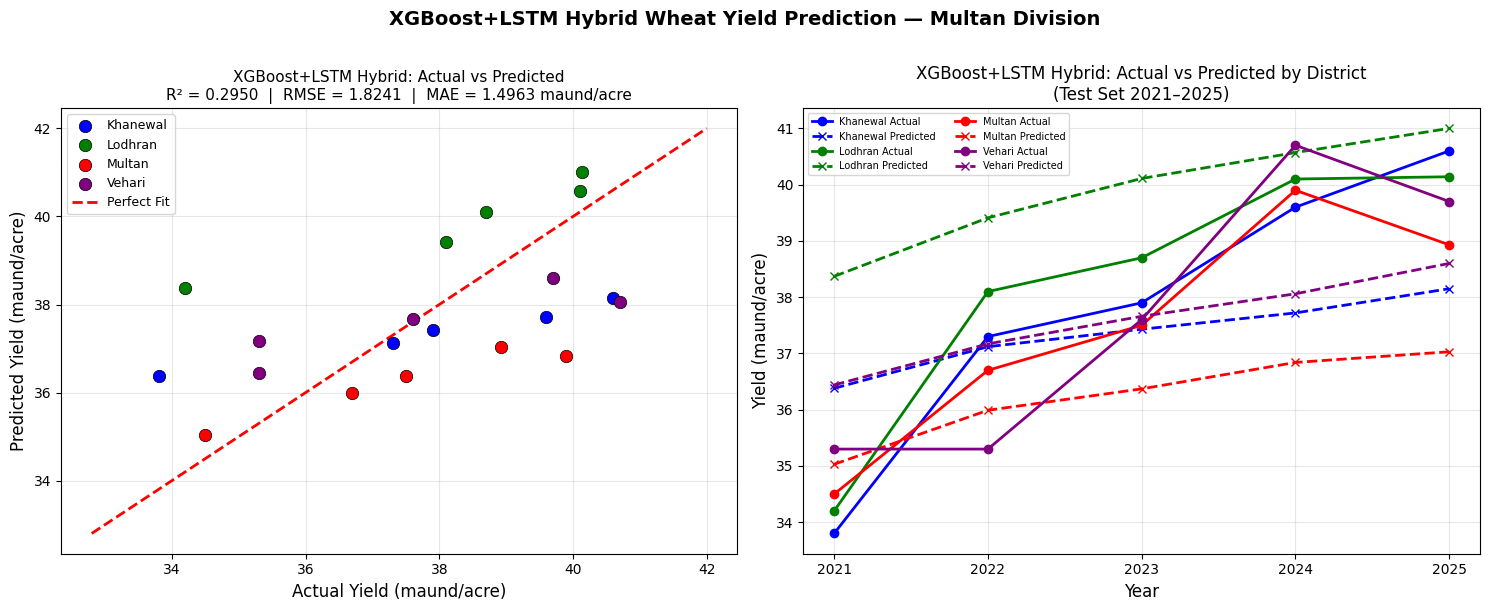

Plot saved to SERWI_Results folder.


In [ ]:
# ============================================================
# CELL 3: Results Table + Actual vs Predicted Plots
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

colors_dist = {
    'Khanewal': 'blue', 'Lodhran': 'green',
    'Multan': 'red',    'Vehari': 'purple'
}

results_hybrid = pd.DataFrame({
    'Year':      yr_labels,
    'District':  dist_labels,
    'Actual':    y_true.round(2),
    'Predicted': y_pred_hybrid.round(2),
    'Error':     (y_true - y_pred_hybrid).round(2)
})

print('Actual vs Predicted (Test Set 2021-2025):')
print(results_hybrid.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    mask = results_hybrid['District'] == dist
    ax1.scatter(
        results_hybrid.loc[mask, 'Actual'],
        results_hybrid.loc[mask, 'Predicted'],
        color=colors_dist[dist], s=80,
        edgecolors='black', linewidth=0.5,
        label=dist, zorder=3
    )
mn = min(results_hybrid['Actual'].min(), results_hybrid['Predicted'].min()) - 1
mx = max(results_hybrid['Actual'].max(), results_hybrid['Predicted'].max()) + 1
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax1.set_xlabel('Actual Yield (maund/acre)', fontsize=12)
ax1.set_ylabel('Predicted Yield (maund/acre)', fontsize=12)
ax1.set_title(
    f'XGBoost+LSTM Hybrid: Actual vs Predicted\n'
    f'R² = {r2_hyb:.4f}  |  RMSE = {rmse_hyb:.4f}  |  MAE = {mae_hyb:.4f} maund/acre',
    fontsize=11
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for dist in districts:
    sub = results_hybrid[results_hybrid['District'] == dist].sort_values('Year')
    ax2.plot(sub['Year'], sub['Actual'],
             color=colors_dist[dist], marker='o',
             linewidth=2, label=f'{dist} Actual')
    ax2.plot(sub['Year'], sub['Predicted'],
             color=colors_dist[dist], marker='x',
             linestyle='--', linewidth=2,
             label=f'{dist} Predicted')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Yield (maund/acre)', fontsize=12)
ax2.set_title(
    'XGBoost+LSTM Hybrid: Actual vs Predicted by District\n(Test Set 2021–2025)',
    fontsize=12
)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.suptitle(
    'XGBoost+LSTM Hybrid Wheat Yield Prediction — Multan Division',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_XGB_LSTM_Actual_vs_Predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to SERWI_Results folder.')

=== RESIDUAL STATISTICS ===
Mean   : 0.0560
Std    : 1.8702
Min    : -4.1700
Max    : 3.0600

Within ±2 maund/acre: 15/20 = 75.0%
Within ±3 maund/acre: 18/20 = 90.0%


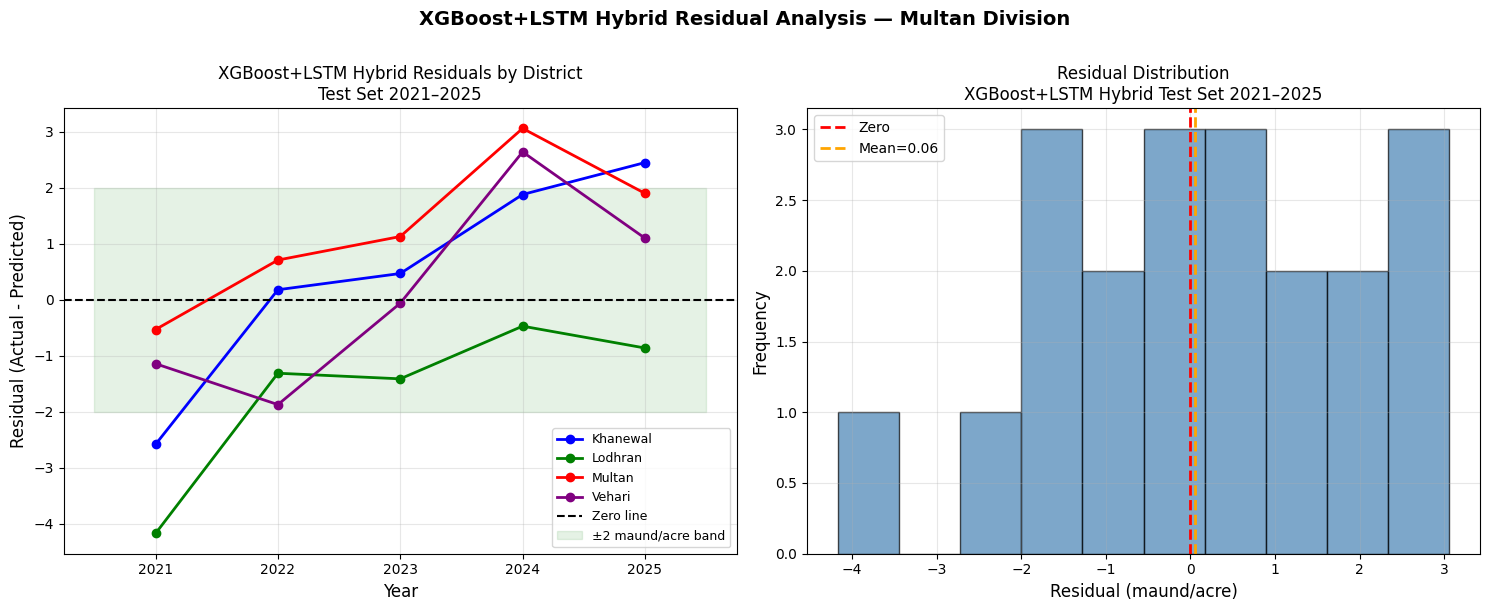

Residual plot saved to SERWI_Results folder.


In [ ]:
# ============================================================
# CELL 4: Residual Analysis
# ============================================================
results_hybrid['Residual'] = results_hybrid['Actual'] - results_hybrid['Predicted']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    sub = results_hybrid[results_hybrid['District'] == dist].sort_values('Year')
    ax1.plot(sub['Year'], sub['Residual'],
             color=colors_dist[dist], marker='o', linewidth=2, label=dist)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero line')
ax1.fill_between([2020.5, 2025.5], -2, 2,
                  alpha=0.1, color='green', label='±2 maund/acre band')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title('XGBoost+LSTM Hybrid Residuals by District\nTest Set 2021–2025', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([2021, 2022, 2023, 2024, 2025])

ax2 = axes[1]
ax2.hist(results_hybrid['Residual'], bins=10,
         color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax2.axvline(results_hybrid['Residual'].mean(), color='orange',
            linestyle='--', linewidth=2,
            label=f'Mean={results_hybrid["Residual"].mean():.2f}')
ax2.set_xlabel('Residual (maund/acre)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution\nXGBoost+LSTM Hybrid Test Set 2021–2025', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

within_2 = (results_hybrid['Residual'].abs() <= 2).sum()
within_3 = (results_hybrid['Residual'].abs() <= 3).sum()
total    = len(results_hybrid)

print('=== RESIDUAL STATISTICS ===')
print(f'Mean   : {results_hybrid["Residual"].mean():.4f}')
print(f'Std    : {results_hybrid["Residual"].std():.4f}')
print(f'Min    : {results_hybrid["Residual"].min():.4f}')
print(f'Max    : {results_hybrid["Residual"].max():.4f}')
print()
print(f'Within ±2 maund/acre: {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'Within ±3 maund/acre: {within_3}/{total} = {within_3/total*100:.1f}%')

plt.suptitle('XGBoost+LSTM Hybrid Residual Analysis — Multan Division',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_XGB_LSTM_Residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Residual plot saved to SERWI_Results folder.')

In [ ]:
# ============================================================
# CELL 5: Save Results to SERWI_Results Folder
# ============================================================
import numpy as np

# Save predictions — with SERWI_ prefix in new folder
np.save(DRIVE_PATH + 'SERWI_xgb_lstm_y_pred_test.npy',  y_pred_hybrid)
np.save(DRIVE_PATH + 'SERWI_xgb_lstm_y_test.npy',        y_true)
np.save(DRIVE_PATH + 'SERWI_xgb_lstm_yr_test.npy',       lstm_yr_test)
np.save(DRIVE_PATH + 'SERWI_xgb_lstm_dist_test.npy',     lstm_dist_test)

results_hybrid.to_csv(
    DRIVE_PATH + 'SERWI_XGB_LSTM_Results_Table.csv', index=False)

print('=' * 55)
print('  XGBoost + LSTM HYBRID — FINAL SUMMARY')
print('=' * 55)
print(f'  Method         : Error-Decorrelation Blend')
print(f'  XGB weight     : {w_xgb:.4f}')
print(f'  LSTM weight    : {w_lstm:.4f}')
print(f'  Train period   : 2002–2020')
print(f'  Test period    : 2021–2025 (20 samples)')
print(f'  Districts      : Khanewal, Lodhran, Multan, Vehari')
print()
print(f'  Test R²        : {r2_hyb:.4f}')
print(f'  Test RMSE      : {rmse_hyb:.4f} maund/acre')
print(f'  Test MAE       : {mae_hyb:.4f} maund/acre')
print()
print(f'  Mean Residual  : {results_hybrid["Residual"].mean():.4f}')
print(f'  Within ±2      : {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'  Within ±3      : {within_3}/{total} = {within_3/total*100:.1f}%')
print('=' * 55)
print()
print('=== FULL MODEL COMPARISON ===')
print(f'  {"Model":<22} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 50)
print(f'  {"XGBoost":<22} {r2_xgb:>8.4f} {rmse_xgb:>8.4f} {mae_xgb:>8.4f}')
print(f'  {"LSTM":<22} {r2_lstm:>8.4f} {rmse_lstm:>8.4f} {mae_lstm:>8.4f}')
print(f'  {"XGB+LSTM Hybrid":<22} {r2_hyb:>8.4f} {rmse_hyb:>8.4f} {mae_hyb:>8.4f}')
print(f'  {"TCN":<22} {"0.4849":>8} {"1.5592":>8} {"1.3436":>8}')
print('=' * 55)
print()
print('Files saved to SERWI_Results/:')
print('  ✓ SERWI_xgb_lstm_y_pred_test.npy')
print('  ✓ SERWI_xgb_lstm_y_test.npy')
print('  ✓ SERWI_xgb_lstm_yr_test.npy')
print('  ✓ SERWI_xgb_lstm_dist_test.npy')
print('  ✓ SERWI_XGB_LSTM_Results_Table.csv')
print('  ✓ SERWI_XGB_LSTM_Actual_vs_Predicted.png')
print('  ✓ SERWI_XGB_LSTM_Residuals.png')
print()
print('Old files in Colab Notebooks/ are untouched.')
print('XGBoost+LSTM complete. Next: LSTM+TCN with SERWI.')

  XGBoost + LSTM HYBRID — FINAL SUMMARY
  Method         : Error-Decorrelation Blend
  XGB weight     : 0.1000
  LSTM weight    : 0.9000
  Train period   : 2002–2020
  Test period    : 2021–2025 (20 samples)
  Districts      : Khanewal, Lodhran, Multan, Vehari

  Test R²        : 0.2950
  Test RMSE      : 1.8241 maund/acre
  Test MAE       : 1.4963 maund/acre

  Mean Residual  : 0.0560
  Within ±2      : 15/20 = 75.0%
  Within ±3      : 18/20 = 90.0%

=== FULL MODEL COMPARISON ===
  Model                        R²     RMSE      MAE
  --------------------------------------------------
  XGBoost                  0.1698   1.9794   1.5916
  LSTM                     0.2945   1.8247   1.5002
  XGB+LSTM Hybrid          0.2950   1.8241   1.4963
  TCN                      0.4849   1.5592   1.3436

Files saved to SERWI_Results/:
  ✓ SERWI_xgb_lstm_y_pred_test.npy
  ✓ SERWI_xgb_lstm_y_test.npy
  ✓ SERWI_xgb_lstm_yr_test.npy
  ✓ SERWI_xgb_lstm_dist_test.npy
  ✓ SERWI_XGB_LSTM_Results_Table.csv
  ✓

SHAP values computed ✓


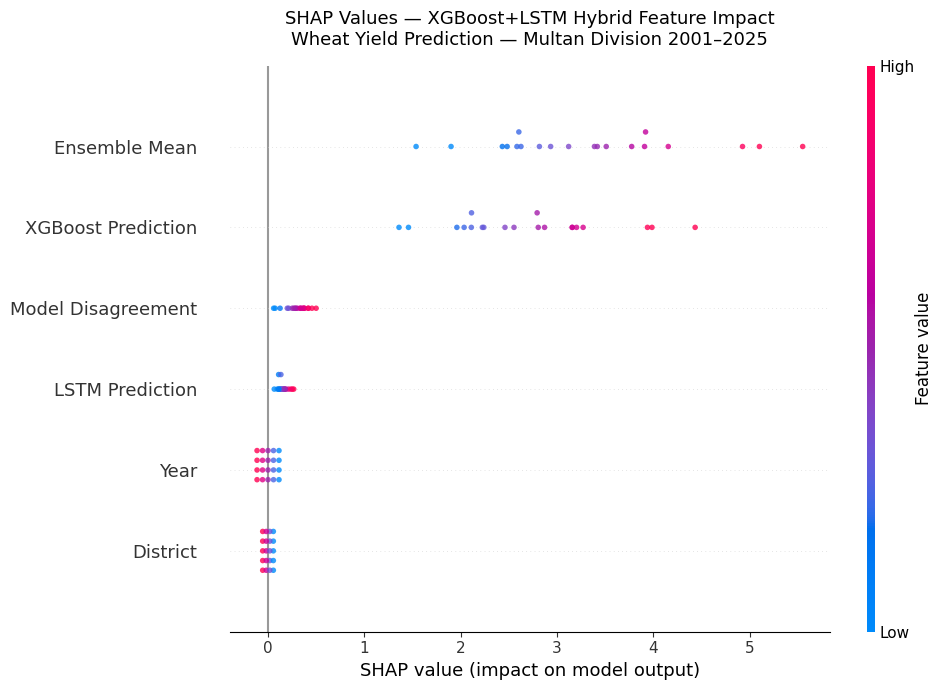

SHAP beeswarm saved.


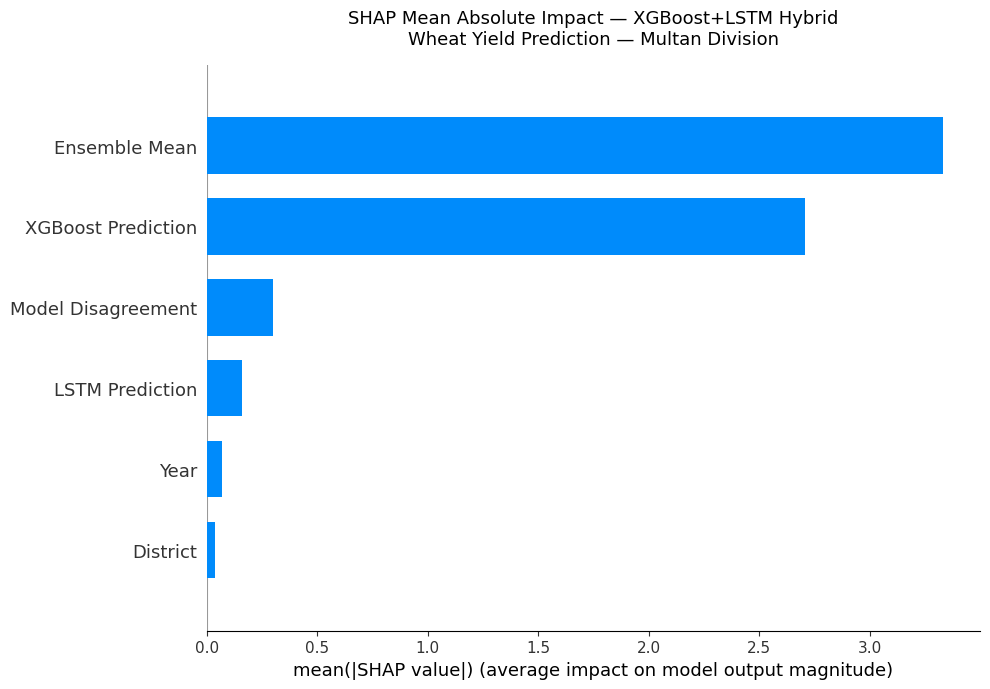

SHAP bar saved.

=== SHAP MEAN ABSOLUTE VALUES ===
           Feature  Mean_SHAP
     Ensemble Mean   3.333232
XGBoost Prediction   2.705657
Model Disagreement   0.300084
   LSTM Prediction   0.157213
              Year   0.068342
          District   0.036889

Files saved to SERWI_Results/:
  ✓ SERWI_XGB_LSTM_SHAP_Summary.png
  ✓ SERWI_XGB_LSTM_SHAP_Bar.png


In [ ]:
# ============================================================
# CELL 6: SHAP Analysis
# ============================================================
!pip install shap --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge

le = LabelEncoder()
le.fit(districts)

dist_enc_test  = le.transform(lstm_dist_test)
yr_norm_test   = (lstm_yr_test - lstm_yr_test.min()) / (lstm_yr_test.max() - lstm_yr_test.min())

X_shap_test = np.column_stack([
    xgb_y_pred_test, lstm_y_pred_test,
    xgb_y_pred_test - lstm_y_pred_test,
    (xgb_y_pred_test + lstm_y_pred_test) / 2,
    yr_norm_test, dist_enc_test
])

dist_enc_train = le.transform(
    np.array(['Khanewal']*16+['Lodhran']*16+['Multan']*16+['Vehari']*16))
yr_norm_train  = (np.tile(np.arange(2005,2021),4)[:64]-2005)/15.0

X_shap_train = np.column_stack([
    xgb_y_pred_train_aligned, lstm_y_pred_train_aligned,
    xgb_y_pred_train_aligned - lstm_y_pred_train_aligned,
    (xgb_y_pred_train_aligned + lstm_y_pred_train_aligned) / 2,
    yr_norm_train, dist_enc_train
])

feature_names = [
    'XGBoost Prediction', 'LSTM Prediction',
    'Model Disagreement', 'Ensemble Mean',
    'Year', 'District'
]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_shap_train)
X_test_s  = scaler.transform(X_shap_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, xgb_y_train_aligned)

explainer   = shap.LinearExplainer(ridge, X_train_s)
shap_values = explainer.shap_values(X_test_s)
print('SHAP values computed ✓')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_s,
                  feature_names=feature_names, show=False,
                  plot_size=(10, 7), alpha=0.8)
plt.title('SHAP Values — XGBoost+LSTM Hybrid Feature Impact\n'
          'Wheat Yield Prediction — Multan Division 2001–2025',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_XGB_LSTM_SHAP_Summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm saved.')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_s,
                  feature_names=feature_names, plot_type='bar',
                  show=False, plot_size=(10, 7))
plt.title('SHAP Mean Absolute Impact — XGBoost+LSTM Hybrid\n'
          'Wheat Yield Prediction — Multan Division',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_XGB_LSTM_SHAP_Bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar saved.')

shap_df = pd.DataFrame({
    'Feature':   feature_names,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print()
print('=== SHAP MEAN ABSOLUTE VALUES ===')
print(shap_df.to_string(index=False))
print()
print('Files saved to SERWI_Results/:')
print('  ✓ SERWI_XGB_LSTM_SHAP_Summary.png')
print('  ✓ SERWI_XGB_LSTM_SHAP_Bar.png')